### Use text mining techniques to analyse a collection of news articles. Identify the most frequent terms and perform topic modelling using Latent Dirichlet Allocation (LDA) to find hidden topics within the articles.

In [1]:
import pandas as pd
import numpy as np
import re, glob, os
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from nltk.stem import PorterStemmer

In [2]:
files = glob.glob("data_exp8/Summaries/**/*.txt", recursive=True)

if not files:
    raise FileNotFoundError("No .txt files found.")

df = pd.DataFrame({
    "filename": [os.path.relpath(f, "data_exp8/Summaries") for f in files],
    "text": [open(f, encoding="utf-8").read() for f in files]
})

print(f"Loaded {len(df)} articles.")

Loaded 2225 articles.


In [3]:
stemmer = PorterStemmer()

def preprocess(text):
    text = re.sub(r"http\S+|www\S+|https\S+|[^a-zA-Z\s]", " ", text.lower())
    return " ".join(
        stemmer.stem(w) for w in text.split()
        if w not in ENGLISH_STOP_WORDS and len(w) > 2
    )

df["clean_text"] = df.text.apply(preprocess)

In [4]:
vectorizer = CountVectorizer(max_df=0.9, min_df=2)
X = vectorizer.fit_transform(df.clean_text)
features = vectorizer.get_feature_names_out()

print("Matrix shape:", X.shape)

Matrix shape: (2225, 7597)


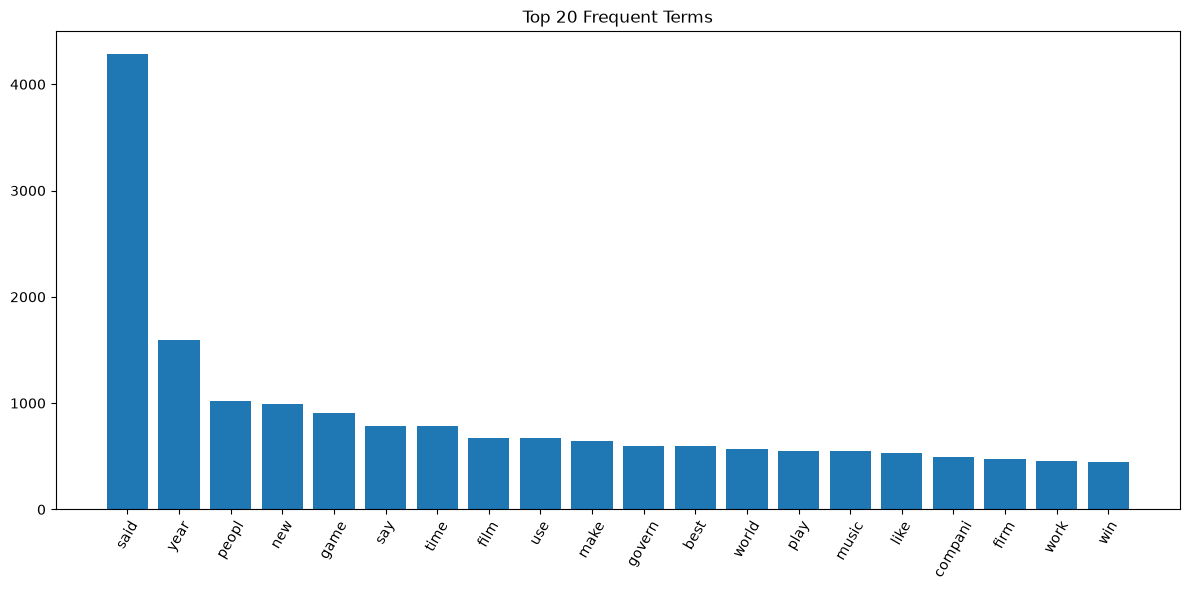

In [5]:
freq = np.asarray(X.sum(axis=0)).ravel()
idx = freq.argsort()[-20:][::-1]

plt.figure(figsize=(12, 6))
plt.bar(features[idx], freq[idx])
plt.xticks(rotation=60)
plt.title("Top 20 Frequent Terms")
plt.tight_layout()
plt.show()

In [6]:
num_topics = 5

lda = LatentDirichletAllocation(
    n_components=num_topics,
    max_iter=20,
    random_state=42
).fit(X)

In [7]:
for i, topic in enumerate(lda.components_):
    words = features[topic.argsort()[-10:][::-1]]
    print(f"Topic {i + 1}: {', '.join(words)}")

Topic 1: game, said, play, win, year, england, time, world, player, final
Topic 2: said, year, sale, bank, economi, club, month, growth, price, share
Topic 3: said, peopl, govern, say, use, firm, law, compani, new, secur
Topic 4: said, game, peopl, mobil, music, use, phone, technolog, servic, year
Topic 5: said, film, labour, best, elect, parti, blair, award, brown, lord


In [8]:
topics = lda.transform(X)

topic_df = pd.DataFrame(
    topics,
    columns=[f"Topic_{i+1}" for i in range(num_topics)]
)

topic_df.insert(0, "filename", df.filename)
topic_df.head(10)

,filename,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
0,entertainment/321.txt,0.002296,0.452190,0.002276,0.540958,0.002280
1,entertainment/240.txt,0.004443,0.982172,0.004437,0.004481,0.004467
2,entertainment/086.txt,0.002252,0.002221,0.002205,0.002207,0.991115
3,entertainment/122.txt,0.449268,0.125320,0.001432,0.165914,0.258066
4,entertainment/180.txt,0.239789,0.205154,0.176871,0.003902,0.374285
5,entertainment/206.txt,0.003213,0.581524,0.003201,0.220115,0.191947
6,entertainment/102.txt,0.004316,0.235813,0.004292,0.036106,0.719473
7,entertainment/305.txt,0.072849,0.001573,0.060395,0.686985,0.178197
8,entertainment/269.txt,0.003857,0.003819,0.003835,0.003908,0.984582
9,entertainment/099.txt,0.003787,0.003790,0.003788,0.003747,0.984888
